<a href="https://colab.research.google.com/github/pallavigeddam/cs207-section5-team4-project/blob/main/Pallavi_Stock_Classification_Full.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stock Movement Classification

Predicting next-day price direction for SPY, NVDA, MU, and TSLA as a 5-class problem.
This notebook runs the full pipeline once (data, 32 features, look-ahead-safe target, split,
EDA), then trains two models on the same data: a multinomial logistic regression baseline and
a TensorFlow LSTM. Run the setup cell once per Colab session, then Run All. A GPU runtime is
recommended for the LSTM.

In [1]:
#  0. Pre-run setup: install + API keys (run this cell first, then Run All) ─
!pip install -q "alpaca-py>=0.13"

import os
os.environ["ALPACA_API_KEY"] = "PKPL6PTRKCM4SAKLTEJOPS56BG"
os.environ["ALPACA_SECRET_KEY"] = "DBBYjabWeyQzJc1ZEbMFBtb2qbnGLRWjKGLNLF6VAGLA"
print("Setup cell done. Keys set:", bool(os.environ.get("ALPACA_API_KEY")))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.5/122.5 kB 3.9 MB/s eta 0:00:00
Setup cell done. Keys set: True


## 1. Setup and Configuration

Everything tunable is in one place. Changing the symbols, the date range, or the
number of classes is a one-line edit here.

In [2]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

# Team-standard settings - ETF , Auto , chip and Semi conductor
SYMBOLS    = ["SPY", "NVDA", "MU", "TSLA"]
START, END = "2016-06-20", "2026-06-20"   # about 10 years of daily bars
TRAIN_FRAC = 0.70                          # 70% train, 15% val, 15% test (chronological , no shuffling)
VAL_FRAC   = 0.15
N_CLASSES  = 5                             # 5-class quantile target (team decision) worst 20% to best 20% (Big , mild , rougly flat , mild ,big jump)
FLAT_K     = 0.33                          # only used if N_CLASSES == 3

USE_SYNTHETIC = False                      # set True to run offline without Alpaca keys
RANDOM_STATE  = 42
# LSTM knobs
WINDOW     = 20      # lookback: days per sequence (~1 month)
EPOCHS     = 30      # max passes; early stopping usually halts sooner
BATCH_SIZE = 64

np.random.seed(RANDOM_STATE)
sns.set_style("whitegrid")
print("Config loaded. Symbols:", SYMBOLS)

Config loaded. Symbols: ['SPY', 'NVDA', 'MU', 'TSLA']


In [3]:
def _synthetic_prices(symbols, start, end):
    # Offline fallback only. Makes fake but realistic-looking price paths
    dates = pd.bdate_range(start=start, end=end)
    n = len(dates); out = {}
    betas = {"SPY": 1.0, "NVDA": 1.7, "MU": 1.4, "TSLA": 1.8}
    for s in symbols:
        r = np.random.normal(4e-4, 0.012 * betas.get(s, 1.2), n)
        close = 100 * np.exp(np.cumsum(r))
        hi = close * (1 + np.abs(np.random.normal(0, 0.006, n)))
        lo = close * (1 - np.abs(np.random.normal(0, 0.006, n)))
        op = lo + (hi - lo) * np.random.rand(n)
        v  = np.random.lognormal(16, 0.4, n)
        df = pd.DataFrame({"open": op, "high": hi, "low": lo, "close": close, "volume": v}, index=dates)
        df.index.name = "date"; df["symbol"] = s
        out[s] = df
    return out

## 2. Data Acquisition

We pull daily OHLCV for each symbol from Alpaca into a dictionary keyed by ticker.
Keeping each symbol in its own frame means a rolling feature can never blend one
ticker's prices into another's.

Two settings matter:
1. `adjustment="all"` so stock splits and dividends are corrected. Without it the
   NVDA 10-for-1 (June 2024) and TSLA 3-for-1 (Aug 2022) splits show up as fake
   one-day crashes and poison the labels. Alpaca defaults to raw prices, so we set this on purpose.
2. Keys are read from environment variables, never typed into a cell.

In [4]:
def download_prices(symbols, start, end, feed="iex"):
    # Pull split/dividend-adjusted daily bars from Alpaca.
    import getpass
    from alpaca.data.historical import StockHistoricalDataClient
    from alpaca.data.requests import StockBarsRequest
    from alpaca.data.timeframe import TimeFrame
    from alpaca.data.enums import Adjustment, DataFeed

    key    = os.environ.get("ALPACA_API_KEY")    or getpass.getpass("Alpaca API key: ")
    secret = os.environ.get("ALPACA_SECRET_KEY") or getpass.getpass("Alpaca secret key: ")
    client = StockHistoricalDataClient(key, secret)

    req = StockBarsRequest(
        symbol_or_symbols=list(symbols),
        timeframe=TimeFrame.Day,
        start=pd.Timestamp(start), end=pd.Timestamp(end),
        adjustment=Adjustment.ALL,                              # the important fix
        feed=DataFeed.SIP if feed.lower() == "sip" else DataFeed.IEX,
    )
    bars = client.get_stock_bars(req).df    # MultiIndex (symbol, timestamp)

    out = {}
    for s in symbols:
        d = bars.loc[s].copy()
        idx = pd.DatetimeIndex(d.index)
        if idx.tz is not None:
            idx = idx.tz_localize(None)      # drop timezone, keep the calendar date
        d.index = idx.normalize(); d.index.name = "date"
        d = d[["open", "high", "low", "close", "volume"]].copy()
        d["symbol"] = s
        out[s] = d
    return out

if USE_SYNTHETIC:
    raw = _synthetic_prices(SYMBOLS, START, END)
    print("USING SYNTHETIC DATA (offline mode)")
else:
    raw = download_prices(SYMBOLS, START, END, feed="iex")
    print("Downloaded real data from Alpaca (adjustment=all, IEX feed)")

for s in SYMBOLS:
    print(f"  {s:5s} {raw[s].shape[0]:>5d} rows | {raw[s].index.min().date()} to {raw[s].index.max().date()}")

# total rows before any feature warmup is dropped (report this in the milestone)
rows_before = sum(raw[s].shape[0] for s in SYMBOLS)
print("Total raw rows across all symbols:", rows_before)
raw["SPY"].head()

Downloaded real data from Alpaca (adjustment=all, IEX feed)
  SPY    1483 rows | 2018-11-01 to 2026-06-18
  NVDA   1482 rows | 2020-07-27 to 2026-06-18
  MU     1482 rows | 2020-07-27 to 2026-06-18
  TSLA   1482 rows | 2020-07-27 to 2026-06-18
Total raw rows across all symbols: 5929


,open,high,low,close,volume,symbol
date,,,,,,
2018-11-01,241.54,241.54,241.54,241.54,200.0,SPY
2020-07-27,296.17,297.80,295.43,297.68,647693.0,SPY
2020-07-28,297.04,298.02,295.46,295.82,521475.0,SPY
2020-07-29,296.63,299.93,296.63,299.43,600377.0,SPY
2020-07-30,296.25,298.71,294.34,298.32,612074.0,SPY


## 3. Feature Engineering

All features are built per symbol and are **stationary** on purpose: returns, ratios,
and bounded indicators instead of raw price or volume levels. Raw price levels would
keep climbing over 10 years, so anything the scaler learned on the (cheaper) training
years would not match the (pricier) test years. Using returns and ratios avoids that.

The feature groups map to the team's indicator list like this:
- "Lagged price" becomes **momentum** over 10/20/30/50/100/200 days (return over k days).
- "Lagged volume" becomes **volume ratios** (volume vs its own moving average).
- SMAs (10/20/50/100/200) become **price-to-MA distance** so they stay comparable across years.
- RSI, MACD, and Bollinger %b are standard.
- Six extra indicators the team added (ATR, ADX, MFI, CMF, daily range, overnight gap)
  bring the total to 32, all kept stationary by dividing through by price.

In [5]:
def add_features(df):
    # Work on one symbol at a time, sorted oldest to newest.
    df = df.sort_index().copy()
    close = df["close"]
    vol   = df["volume"]

    # daily returns (the core signal)
    df["ret_1"]   = close.pct_change()
    df["log_ret"] = np.log(close).diff()

    # yesterday / 2 days ago / 3 days ago returns (short-term memory)
    for lag in (1, 2, 3):
        df[f"ret_lag{lag}"] = df["ret_1"].shift(lag)

    # momentum over several horizons = return over the last k days
    # (this is the stationary stand-in for "lagged price")
    for k in (10, 20, 30, 50, 100, 200):
        df[f"mom_{k}"] = close / close.shift(k) - 1

    # moving averages: keep the raw MA for plotting, but feed the model the
    # distance from price to the MA (a ratio), which stays on the same scale across years
    for w in (10, 20, 50, 100, 200):
        ma = close.rolling(w).mean()
        df[f"ma_{w}"]         = ma
        df[f"price_to_ma{w}"] = close / ma - 1
    df["ma_cross"] = df["ma_50"] / df["ma_200"] - 1   # 50/200 crossover (golden vs death cross)

    # RSI (14, Wilder smoothing)
    delta = close.diff()
    gain  = delta.clip(lower=0)
    loss  = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    df["rsi_14"] = 100 - 100 / (1 + avg_gain / avg_loss)

    # MACD (12/26 EMAs, 9-day signal). Divided by price so the scale is stable over 10 years.
    ema12 = close.ewm(span=12, adjust=False).mean()
    ema26 = close.ewm(span=26, adjust=False).mean()
    df["macd"]        = (ema12 - ema26) / close
    df["macd_signal"] = df["macd"].ewm(span=9, adjust=False).mean()
    df["macd_hist"]   = df["macd"] - df["macd_signal"]

    # Bollinger Bands turned into %b: where price sits inside the 20-day band (0 = bottom, 1 = top)
    mid   = close.rolling(20).mean()
    sd    = close.rolling(20).std()
    upper = mid + 2 * sd
    lower = mid - 2 * sd
    df["bb_pct"] = (close - lower) / (upper - lower)

    # realized volatility and how busy volume is vs its own average
    df["volatility_20"] = df["ret_1"].rolling(20).std()
    for w in (10, 20, 50):
        df[f"vol_ratio{w}"] = vol / vol.rolling(w).mean()

    # --- six extra indicators the team converged on (Ron + Vansh), all kept stationary ---
    high = df["high"]; low = df["low"]; openp = df["open"]
    prev_close = close.shift(1)

    # daily high-low range and overnight gap (both as a fraction of price)
    df["range_hl"] = (high - low) / close
    df["gap"]      = (openp - prev_close) / prev_close

    # ATR (14): average true range as volatility, divided by price to stay stationary
    tr = pd.concat([(high - low), (high - prev_close).abs(), (low - prev_close).abs()], axis=1).max(axis=1)
    atr_raw = tr.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    df["atr_14"] = atr_raw / close

    # ADX (14): trend strength from the +DI / -DI directional movement
    up_move   = high.diff()
    down_move = -low.diff()
    plus_dm  = pd.Series(np.where((up_move > down_move) & (up_move > 0), up_move, 0.0), index=df.index)
    minus_dm = pd.Series(np.where((down_move > up_move) & (down_move > 0), down_move, 0.0), index=df.index)
    plus_di  = 100 * plus_dm.ewm(alpha=1/14, min_periods=14, adjust=False).mean() / atr_raw
    minus_di = 100 * minus_dm.ewm(alpha=1/14, min_periods=14, adjust=False).mean() / atr_raw
    dx = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di)
    df["adx_14"] = dx.ewm(alpha=1/14, min_periods=14, adjust=False).mean()

    # MFI (14): like RSI but weighted by volume
    typical    = (high + low + close) / 3
    money_flow = typical * vol
    pos_mf = money_flow.where(typical > typical.shift(1), 0.0).rolling(14).sum()
    neg_mf = money_flow.where(typical < typical.shift(1), 0.0).rolling(14).sum()
    df["mfi_14"] = 100 - 100 / (1 + pos_mf / neg_mf)

    # CMF (20): Chaikin Money Flow, money flowing in vs out over 20 days
    denom = (high - low).replace(0, np.nan)
    mfm = ((close - low) - (high - close)) / denom
    mfv = mfm * vol
    df["cmf_20"] = mfv.rolling(20).sum() / vol.rolling(20).sum()

    # label source: NEXT day's return. Used ONLY to build the target, never as a feature.
    df["fwd_ret"] = close.pct_change().shift(-1)
    return df

feat = {s: add_features(raw[s]) for s in SYMBOLS}

# the columns the model actually sees (all stationary; raw price/MA levels are left out)
FEATURE_COLS = (
    ["ret_1", "log_ret", "ret_lag1", "ret_lag2", "ret_lag3"]
    + [f"mom_{k}" for k in (10, 20, 30, 50, 100, 200)]
    + [f"price_to_ma{w}" for w in (10, 20, 50, 100, 200)]
    + ["ma_cross", "rsi_14", "macd", "macd_signal", "macd_hist", "bb_pct", "volatility_20"]
    + [f"vol_ratio{w}" for w in (10, 20, 50)]
    + ["atr_14", "adx_14", "mfi_14", "cmf_20", "range_hl", "gap"]
)
print(f"{len(FEATURE_COLS)} features per symbol")
feat["SPY"][["close", "mom_20", "rsi_14", "macd", "fwd_ret"]].tail()

32 features per symbol


,close,mom_20,rsi_14,macd,fwd_ret
date,,,,,
2026-06-12,739.76,-0.008604,52.952576,0.005120,0.017641
2026-06-15,752.81,0.021175,60.460227,0.006015,-0.005526
2026-06-16,748.65,0.016497,57.320131,0.006312,-0.012730
2026-06-17,739.12,0.009851,50.809776,0.005501,0.010323
2026-06-18,746.75,0.009927,55.197286,0.005506,NaN


## 4. Target Construction (look-ahead safe)

The label is the **next** day's move. The important detail: we assign the train/val/test
split first, then compute the class cut points from the **training rows only** and apply
those fixed cut points to val and test. If we computed the cut points on the whole dataset
(like a plain `qcut` on everything), the class boundaries would secretly know the future.
That is the bias we are avoiding.

- 5-class (default): quantile buckets (worst 20% up to best 20%), edges fit on train only.
- 3-class option: Up / Flat / Down using a volatility-scaled flat band, also from train only.

In [6]:
# global chronological split, shared across all symbols so they use the same cutoff dates
all_dates = sorted(set().union(*[set(feat[s].index) for s in SYMBOLS]))
N = len(all_dates)
TRAIN_END = all_dates[int(N * TRAIN_FRAC)]
VAL_END   = all_dates[int(N * (TRAIN_FRAC + VAL_FRAC))]
print(f"train <= {TRAIN_END.date()} | val <= {VAL_END.date()} | test > {VAL_END.date()}")

def split_tag(idx):
    if idx <= TRAIN_END: return "train"
    if idx <= VAL_END:   return "val"
    return "test"

def label_targets(df):
    df = df.copy()
    df["split"] = [split_tag(i) for i in df.index]
    train_fwd = df.loc[df.split == "train", "fwd_ret"].dropna()   # cut points come from train only

    if N_CLASSES == 3:
        tau = FLAT_K * train_fwd.std()           # flat band scaled by this symbol's volatility
        def lab(r):
            if pd.isna(r): return np.nan
            if r >  tau:   return 2               # Up
            if r < -tau:   return 0               # Down
            return 1                              # Flat
        df["target"] = df["fwd_ret"].apply(lab)
        df.attrs["cuts"] = ("tau", round(tau, 5))
    else:
        q = train_fwd.quantile([0.2, 0.4, 0.6, 0.8]).tolist()
        df["target"] = np.digitize(df["fwd_ret"], q).astype(float)
        df.loc[df["fwd_ret"].isna(), "target"] = np.nan
        df.attrs["cuts"] = ("quintiles", [round(x, 5) for x in q])
    return df

feat = {s: label_targets(feat[s]) for s in SYMBOLS}
LABELS = ["Down", "Flat", "Up"] if N_CLASSES == 3 else ["Worst 20%", "20-40%", "40-60%", "60-80%", "Best 20%"]

for s in SYMBOLS:
    dist = feat[s]["target"].value_counts(normalize=True).sort_index().round(3).to_dict()
    print(f"  {s:5s} cuts={feat[s].attrs['cuts'][1]}  dist={dist}")

train <= 2024-09-10 | val <= 2025-07-31 | test > 2025-07-31
  SPY   cuts=[-0.00691, -0.00124, 0.00274, 0.00889]  dist={0.0: 0.184, 1.0: 0.204, 2.0: 0.205, 3.0: 0.229, 4.0: 0.178}
  NVDA  cuts=[-0.0211, -0.00495, 0.00904, 0.02581]  dist={0.0: 0.189, 1.0: 0.203, 2.0: 0.215, 3.0: 0.204, 4.0: 0.19}
  MU    cuts=[-0.01897, -0.00467, 0.00634, 0.01977]  dist={0.0: 0.216, 1.0: 0.181, 2.0: 0.182, 3.0: 0.174, 4.0: 0.248}
  TSLA  cuts=[-0.02569, -0.00573, 0.00819, 0.02907]  dist={0.0: 0.2, 1.0: 0.207, 2.0: 0.198, 3.0: 0.192, 4.0: 0.204}


## 5. Train / Validation / Test Assembly

We stack all symbols into one table, drop the warmup rows that have no features yet
(the first 200 days need history for the long moving averages), and split by the tag we
just assigned. A hard assertion makes sure the forward return and the target never sneak
into the feature list.

In [7]:
# stack all symbols, then treat any inf (e.g. a vol ratio dividing by a zero-volume window) as missing
full = pd.concat([feat[s].assign(symbol=s) for s in SYMBOLS])
full = full.replace([np.inf, -np.inf], np.nan)

# show which columns drive the row drop so it's not a black box
na = full[FEATURE_COLS + ["target"]].isna().sum()
print("NaNs per column (only those with any):")
print(na[na > 0].sort_values(ascending=False).to_string(), "\n")

full = full.dropna(subset=FEATURE_COLS + ["target"]).copy()
full["target"] = full["target"].astype(int)

# safety check: the thing we predict must not be one of the inputs
assert "fwd_ret" not in FEATURE_COLS and "target" not in FEATURE_COLS, "TARGET LEAK!"

def xy(split):
    d = full[full.split == split]
    return d[FEATURE_COLS], d["target"]

Xtr, ytr = xy("train")
Xva, yva = xy("val")
Xte, yte = xy("test")

rows_after = len(full)
print(f"{len(FEATURE_COLS)} features | rows after preprocessing: {rows_after}  (dropped {rows_before - rows_after} warmup/edge rows)")
print(f"  train: {len(Xtr):>5d}  ({full[full.split=='train'].index.min().date()} to {full[full.split=='train'].index.max().date()})")
print(f"  val  : {len(Xva):>5d}  ({full[full.split=='val'].index.min().date()} to {full[full.split=='val'].index.max().date()})")
print(f"  test : {len(Xte):>5d}  ({full[full.split=='test'].index.min().date()} to {full[full.split=='test'].index.max().date()})")

NaNs per column (only those with any):
mom_200           800
price_to_ma200    796
ma_cross          796
mom_100           400
price_to_ma100    396
mom_50            200
price_to_ma50     196
vol_ratio50       196
mom_30            120
adx_14            104
volatility_20      80
mom_20             80
cmf_20             77
bb_pct             76
vol_ratio20        76
price_to_ma20      76
rsi_14             56
mfi_14             52
atr_14             52
mom_10             40
price_to_ma10      36
vol_ratio10        36
ret_lag3           16
ret_lag2           12
ret_lag1            8
ret_1               4
log_ret             4
gap                 4
target              4 

32 features | rows after preprocessing: 5125  (dropped 804 warmup/edge rows)
  train:  3353  (2021-05-11 to 2024-09-10)
  val  :   888  (2024-09-11 to 2025-07-31)
  test :   884  (2025-08-01 to 2026-06-17)


## 6. Exploratory Data Analysis

Five quick views. The written takeaways below each plot describe what we expect to see on
the real Alpaca data.

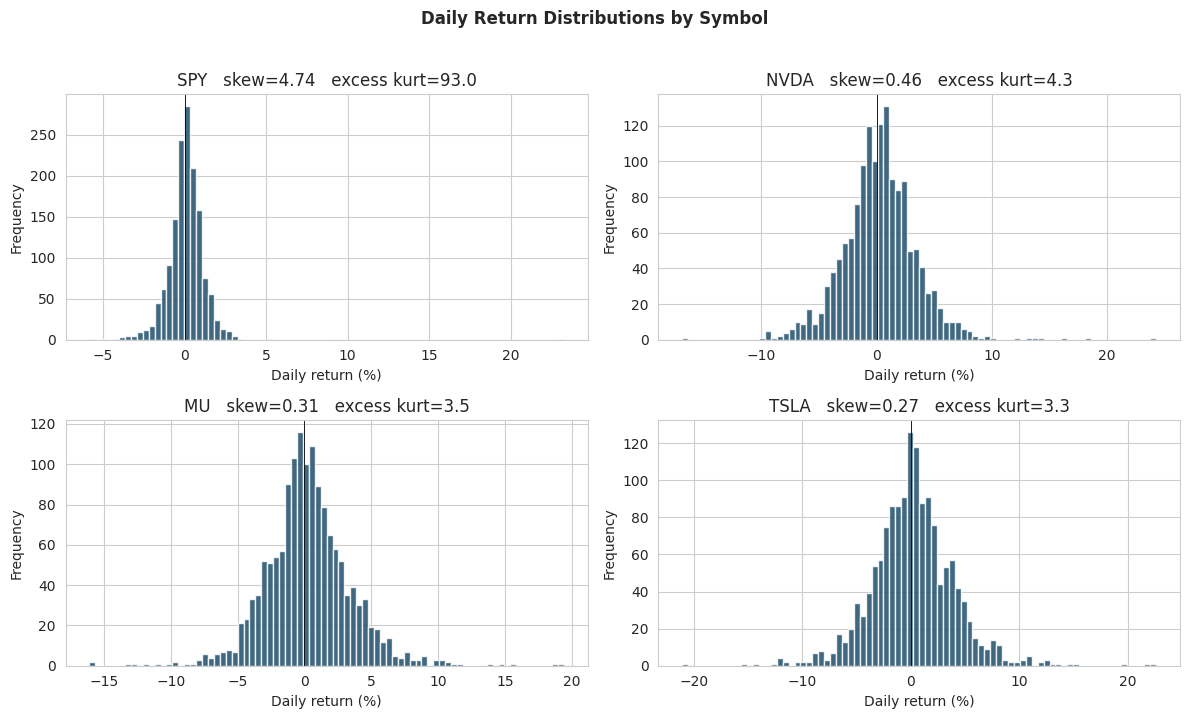

In [8]:
# 6.1 Daily return distributions by symbol
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, s in zip(axes.ravel(), SYMBOLS):
    r = feat[s]["ret_1"].dropna() * 100
    ax.hist(r, bins=80, color="#1f4e6b", alpha=0.85)
    ax.axvline(0, color="k", lw=0.6)
    ax.set_title(f"{s}   skew={skew(r):.2f}   excess kurt={kurtosis(r):.1f}")
    ax.set_xlabel("Daily return (%)"); ax.set_ylabel("Frequency")
fig.suptitle("Daily Return Distributions by Symbol", fontweight="bold", y=1.02)
fig.tight_layout(); plt.show()

**Takeaway.** Returns sit around zero with fat tails (high excess kurtosis), so big moves
happen more often than a normal curve would predict. The model should not assume returns are
Gaussian, and accuracy alone can be misleading, which is why we also track macro F1 later.

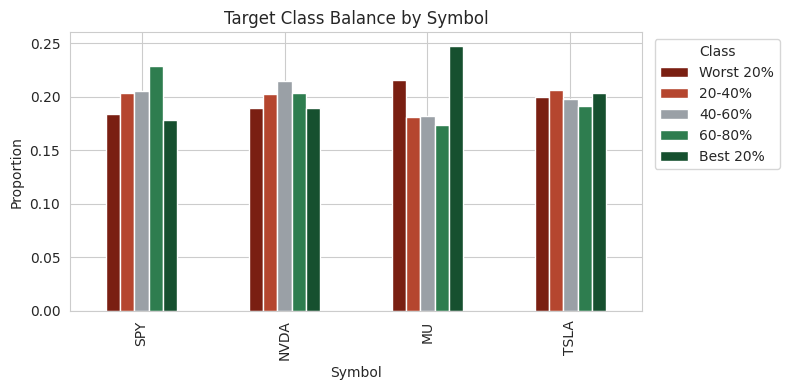

In [9]:
# 6.2 Target class balance per symbol
cb = pd.DataFrame({s: feat[s]["target"].value_counts(normalize=True).sort_index() for s in SYMBOLS})
cb.index = LABELS
colors = ["#b5462f", "#9aa0a6", "#2e7d4f"] if N_CLASSES == 3 else ["#7a1f12", "#b5462f", "#9aa0a6", "#2e7d4f", "#16502f"]
fig, ax = plt.subplots(figsize=(8, 4))
cb.T.plot(kind="bar", ax=ax, color=colors)
ax.set_title("Target Class Balance by Symbol"); ax.set_ylabel("Proportion"); ax.set_xlabel("Symbol")
ax.legend(title="Class", bbox_to_anchor=(1.01, 1)); plt.tight_layout(); plt.show()

**Takeaway.** Because the cut points come from each symbol's own training returns, the
classes start out near 20% each. Small drift in the full-period bars just reflects volatility
changing between the training years and later years.

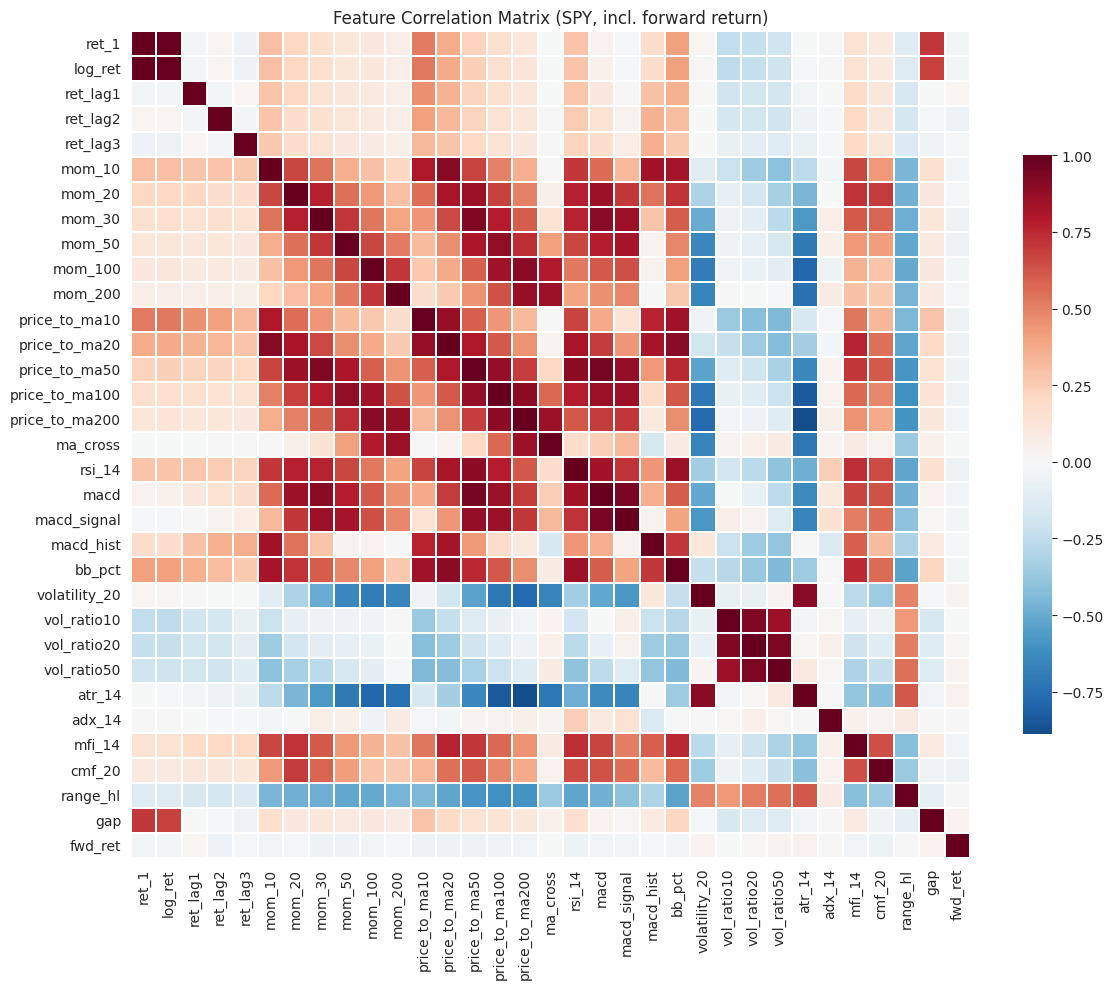

In [10]:
# 6.3 Feature correlation heatmap (SPY), including the forward return
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(feat["SPY"][FEATURE_COLS + ["fwd_ret"]].corr(), cmap="RdBu_r", center=0,
            ax=ax, cbar_kws={"shrink": 0.7}, linewidths=0.3)
ax.set_title("Feature Correlation Matrix (SPY, incl. forward return)")
plt.tight_layout(); plt.show()

**Takeaway.** Look at the `fwd_ret` row: correlations with next-day return are tiny for
every feature. That is the honest reality of daily prediction. The features are more
correlated with each other (the momentum and MA-distance blocks overlap), so the linear model
will see some redundancy.

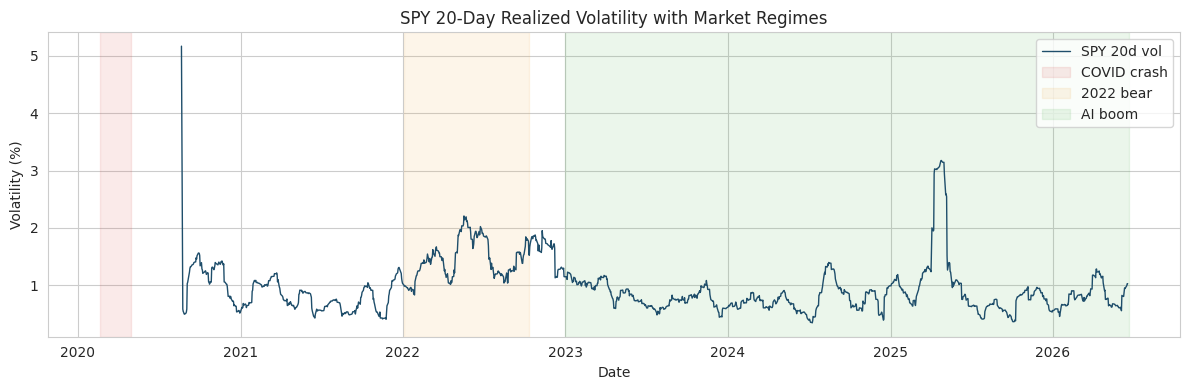

In [11]:
# 6.4 Rolling volatility with market regimes shaded
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(feat["SPY"].index, feat["SPY"]["volatility_20"] * 100, color="#1f4e6b", lw=1, label="SPY 20d vol")
for a, b, col, lbl in [("2020-02-19", "2020-04-30", "#d9534f", "COVID crash"),
                       ("2022-01-03", "2022-10-12", "#f0ad4e", "2022 bear"),
                       ("2023-01-01", str(pd.Timestamp(END).date()), "#5cb85c", "AI boom")]:
    ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color=col, alpha=0.12, label=lbl)
ax.set_title("SPY 20-Day Realized Volatility with Market Regimes")
ax.set_xlabel("Date"); ax.set_ylabel("Volatility (%)"); ax.legend(loc="upper right")
plt.tight_layout(); plt.show()

**Takeaway.** Volatility clusters: calm stretches stay calm, then spike hard in the COVID
crash and the 2022 selloff. One static model has to handle very different regimes, which is why
we shade these periods now for a regime-by-regime check later.

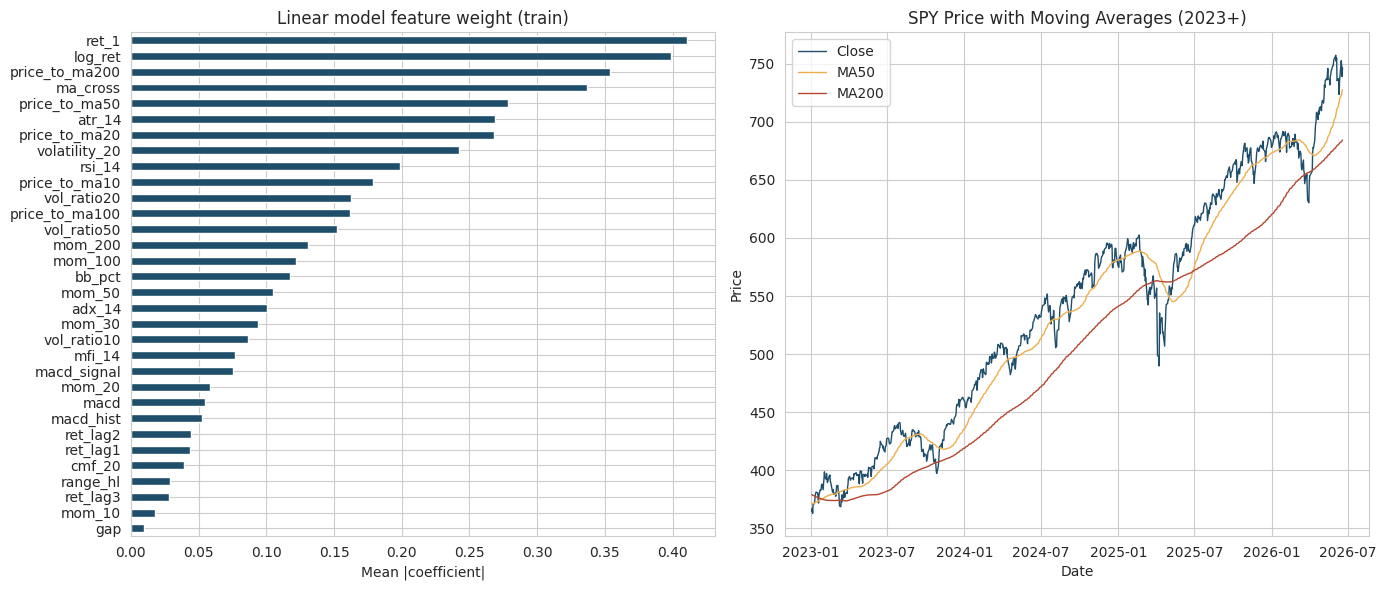

In [12]:
# 6.5 Feature weight from a quick linear fit + price/MA context
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

tr = full[full.split == "train"]
quick_scaler = StandardScaler().fit(tr[FEATURE_COLS])
quick_lr = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
quick_lr.fit(quick_scaler.transform(tr[FEATURE_COLS]), tr["target"])

# average absolute coefficient across the classes = how much weight each feature carries
weight = pd.Series(np.abs(quick_lr.coef_).mean(axis=0), index=FEATURE_COLS).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
weight.plot(kind="barh", ax=axes[0], color="#1f4e6b")
axes[0].set_title("Linear model feature weight (train)"); axes[0].set_xlabel("Mean |coefficient|")

sp = feat["SPY"].loc["2023":]
axes[1].plot(sp.index, sp["close"], label="Close", color="#1f4e6b", lw=1)
axes[1].plot(sp.index, sp["ma_50"], label="MA50", color="#f0ad4e", lw=1)
axes[1].plot(sp.index, sp["ma_200"], label="MA200", color="#b5462f", lw=1)
axes[1].set_title("SPY Price with Moving Averages (2023+)")
axes[1].set_xlabel("Date"); axes[1].set_ylabel("Price"); axes[1].legend()
plt.tight_layout(); plt.show()

**Takeaway.** Weight is spread across momentum, volatility, and the MA-distance features
rather than piling onto one indicator. No single feature dominates, which lines up with the
weak correlations in 6.3.

## 7. Baseline and Linear Model

Two models:
1. **Majority class** (`DummyClassifier`): always predicts the most common training class.
   This is the floor every real model must beat.
2. **Multinomial logistic regression**: our linear model, trained on the scaled features.

The scaler is fit on training data only and reused on val and test. We report accuracy and
macro F1, plus a per-class report and a confusion matrix for the logistic model.

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# scale using train stats only, then apply the same scaler to val and test
scaler = StandardScaler().fit(Xtr)
Xtr_s = scaler.transform(Xtr)
Xva_s = scaler.transform(Xva)
Xte_s = scaler.transform(Xte)

# model 1: majority-class baseline (the floor)
majority = DummyClassifier(strategy="most_frequent").fit(Xtr_s, ytr)
maj_pred = majority.predict(Xte_s)

# model 2: multinomial logistic regression (our linear model)
logreg = LogisticRegression(max_iter=2000, C=1.0, random_state=RANDOM_STATE)
logreg.fit(Xtr_s, ytr)
log_pred = logreg.predict(Xte_s)

print("Test-set results")
print(f"  Majority class : acc={accuracy_score(yte, maj_pred):.3f}  macroF1={f1_score(yte, maj_pred, average='macro'):.3f}")
print(f"  Logistic reg   : acc={accuracy_score(yte, log_pred):.3f}  macroF1={f1_score(yte, log_pred, average='macro'):.3f}")

print("\nPer-class report (logistic regression):")
print(classification_report(yte, log_pred, target_names=LABELS, digits=3, zero_division=0))

Test-set results
  Majority class : acc=0.176  macroF1=0.060
  Logistic reg   : acc=0.182  macroF1=0.168

Per-class report (logistic regression):
              precision    recall  f1-score   support

   Worst 20%      0.163     0.167     0.165       156
      20-40%      0.194     0.114     0.144       175
      40-60%      0.181     0.399     0.249       183
      60-80%      0.134     0.070     0.092       187
    Best 20%      0.240     0.158     0.191       183

    accuracy                          0.182       884
   macro avg      0.182     0.182     0.168       884
weighted avg      0.183     0.182     0.168       884



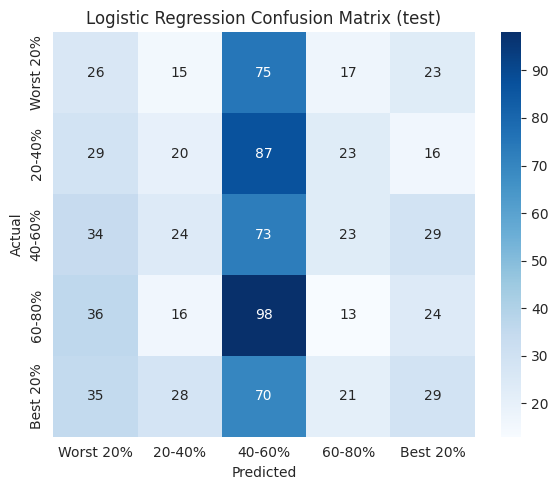

In [14]:
# confusion matrix for the logistic model on the test set
cm = confusion_matrix(yte, log_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Logistic Regression Confusion Matrix (test)")
plt.tight_layout(); plt.show()

**Takeaway.** On daily 5-class direction the linear model only edges out the majority
baseline, which is expected: a single day's move is close to random and a linear boundary can
only capture so much. This is an honest baseline, not a weak result to hide. The nonlinear and
sequence models (XGBoost and a TensorFlow LSTM) come in the next phase and are where we expect
any real lift.

## 7.5 Regime-Stratified Evaluation

This is our distinguishing angle: instead of one aggregate score, we look at how the model
does in different market eras (COVID crash, 2022 bear, AI rally, recent).

Important caveat. With a single chronological split, the COVID and 2022 windows fall inside
the **training** period, so their numbers here are in-sample and therefore optimistic. Only the
recent window is true out-of-sample. The full report will switch to walk-forward validation so
every regime gets scored out-of-sample. This cell is a first exploratory look, not the final
number.

In [15]:
# predict across the whole timeline so we can slice by market regime
full_pred = logreg.predict(scaler.transform(full[FEATURE_COLS]))
full_eval = full.copy()
full_eval["pred"] = full_pred

regimes = {
    "COVID crash (2020)":   ("2020-02-19", "2020-04-30"),
    "2022 bear":            ("2022-01-03", "2022-10-12"),
    "AI rally (2023-2024)": ("2023-01-01", "2024-12-31"),
    "Recent (2025+)":       ("2025-01-01", str(pd.Timestamp(END).date())),
}

rows = []
for name, (a, b) in regimes.items():
    m = (full_eval.index >= pd.Timestamp(a)) & (full_eval.index <= pd.Timestamp(b))
    sub = full_eval[m]
    if len(sub) == 0:
        continue
    # is this window mostly train/val (in-sample) or test (out-of-sample)?
    dominant_split = sub["split"].value_counts(normalize=True).idxmax()
    sample = "out-of-sample" if dominant_split == "test" else "in-sample"
    rows.append({
        "regime": name,
        "n": len(sub),
        "majority_acc": round((sub["target"] == sub["target"].mode()[0]).mean(), 3),
        "logreg_acc":   round(accuracy_score(sub["target"], sub["pred"]), 3),
        "logreg_macroF1": round(f1_score(sub["target"], sub["pred"], average="macro"), 3),
        "window": sample,
    })

regime_tbl = pd.DataFrame(rows)
print(regime_tbl.to_string(index=False))

              regime    n  majority_acc  logreg_acc  logreg_macroF1        window
           2022 bear  784         0.309       0.272           0.239     in-sample
AI rally (2023-2024) 2008         0.217       0.261           0.252     in-sample
      Recent (2025+) 1460         0.220       0.194           0.184 out-of-sample


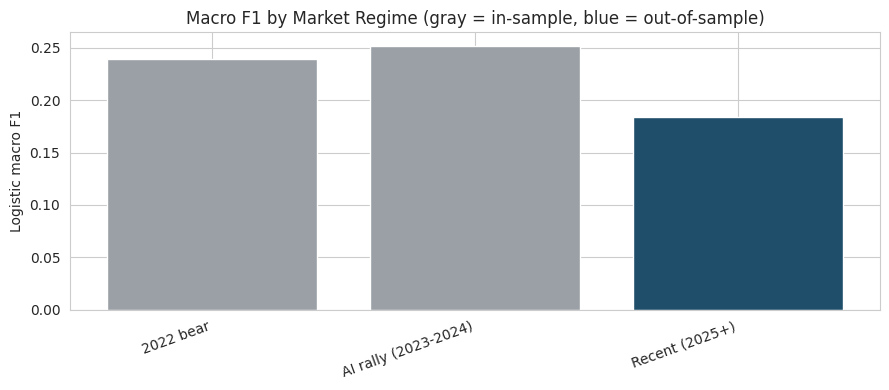

In [16]:
# visualize macro F1 by regime so the contrast is easy to see
fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#9aa0a6" if w == "in-sample" else "#1f4e6b" for w in regime_tbl["window"]]
ax.bar(regime_tbl["regime"], regime_tbl["logreg_macroF1"], color=colors)
ax.set_ylabel("Logistic macro F1"); ax.set_title("Macro F1 by Market Regime (gray = in-sample, blue = out-of-sample)")
ax.set_xticklabels(regime_tbl["regime"], rotation=20, ha="right")
plt.tight_layout(); plt.show()

**Takeaway.** Reading this honestly: the in-sample regimes (gray) will tend to look
stronger simply because the model trained on them, so the fair comparison is the out-of-sample
window (blue). The point of the full-report walk-forward version is to put every regime on equal
footing, which lets us answer the real question: does the model hold up when the market changes,
or does it only work in the conditions it was trained on?

---
# Part 2: LSTM

Everything above produced the table `full` with 32 features, the 5-class target, and the
train/val/test tags. The LSTM reuses that exact data, just reshaped into sequences.

## 8. Building Sequences for the LSTM

A regular model sees one row at a time. An LSTM needs a 3D input shaped
**(samples, timesteps, features)**: for each prediction day it gets the previous `WINDOW`
days stacked together.

Two rules keep this leak-free and correct:
1. **Scale on train only.** We fit a `StandardScaler` on the training rows, then apply it to
   every row. The model never sees test-period statistics.
2. **Build per symbol.** Sequences are built inside each symbol separately so one stock's
   history never slides into another's. Each sequence is assigned to train/val/test by the
   split of its prediction day (the last day in the window). The window may reach back into
   earlier rows, which is fine: those are past, already-known features, never future ones.

In [17]:
from sklearn.preprocessing import StandardScaler

# scaler fit on TRAIN rows only
scaler = StandardScaler().fit(full[full.split == "train"][FEATURE_COLS])

def make_windows(arr, dates, splits, targets, window):
    X, y, d, sp = [], [], [], []
    for i in range(len(arr) - window + 1):
        j = i + window - 1                 # last day in the window = the prediction day
        X.append(arr[i:i + window])
        y.append(targets[j]); d.append(dates[j]); sp.append(splits[j])
    return np.array(X, dtype="float32"), np.array(y), np.array(d), np.array(sp)

Xs, ys, ds, sps = [], [], [], []
for s in SYMBOLS:
    d = full[full.symbol == s].sort_index()
    arr = scaler.transform(d[FEATURE_COLS]).astype("float32")
    Xi, yi, di, spi = make_windows(arr, d.index.values, d["split"].values, d["target"].values, WINDOW)
    Xs.append(Xi); ys.append(yi); ds.append(di); sps.append(spi)

X         = np.concatenate(Xs)
y         = np.concatenate(ys).astype(int)
dates_all = np.concatenate(ds)
split_all = np.concatenate(sps)

def pick(split):
    m = split_all == split
    return X[m], y[m]

Xtr, ytr = pick("train")
Xva, yva = pick("val")
Xte, yte = pick("test")
print("sequence tensor shapes (samples, timesteps, features):")
print("  train", Xtr.shape, "| val", Xva.shape, "| test", Xte.shape)

sequence tensor shapes (samples, timesteps, features):
  train (3277, 20, 32) | val (888, 20, 32) | test (884, 20, 32)


## 9. The LSTM Model

A small network: one LSTM layer reads the 20-day sequence, a dropout layer guards against
overfitting, a dense layer mixes the features, and a softmax outputs the 5 class
probabilities. Early stopping watches the validation loss and keeps the best weights.

In [18]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(RANDOM_STATE)
print("GPU available:", bool(tf.config.list_physical_devices("GPU")))

n_features = X.shape[2]
model = Sequential([
    Input((WINDOW, n_features)),
    LSTM(64),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(N_CLASSES, activation="softmax"),
])
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
history = model.fit(
    Xtr, ytr, validation_data=(Xva, yva),
    epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[es], verbose=1,
)

GPU available: False


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,077 (105.77 KB)

 Trainable params: 27,077 (105.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.2307 - loss: 1.6067 - val_accuracy: 0.2320 - val_loss: 1.5926
Epoch 2/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.2490 - loss: 1.5882 - val_accuracy: 0.2410 - val_loss: 1.5925
Epoch 3/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.2643 - loss: 1.5773 - val_accuracy: 0.2399 - val_loss: 1.5904
Epoch 4/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.2691 - loss: 1.5687 - val_accuracy: 0.2421 - val_loss: 1.5961
Epoch 5/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.2795 - loss: 1.5597 - val_accuracy: 0.2466 - val_loss: 1.5981
Epoch 6/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.2920 - loss: 1.5534 - val_accuracy: 0.2331 - val_loss: 1.6050
Epoch 7/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.3009 - loss: 1.5448 - val_accuracy: 0.2252 - val_loss: 1.6058
Epoch 8/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.3137 - loss: 1.5348 - val_accuracy: 0.2185 - v

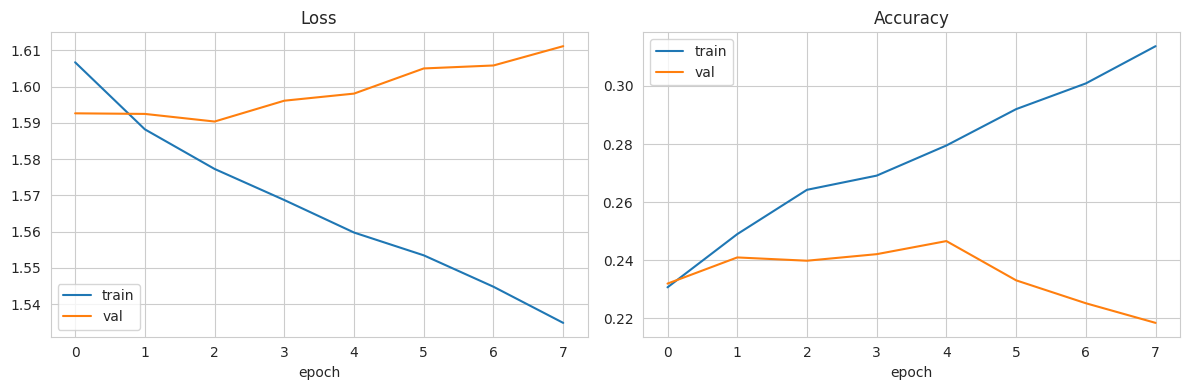

In [19]:
# training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].set_xlabel("epoch"); axes[0].legend()
axes[1].plot(history.history["accuracy"], label="train")
axes[1].plot(history.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("epoch"); axes[1].legend()
plt.tight_layout(); plt.show()

## 10. Evaluation: LSTM vs Logistic vs Baseline

All three are scored on the **same** test sequences. The logistic model is trained on the last
day of each window (`X[:, -1, :]`), so it uses identical samples to the LSTM, which makes the
comparison fair.

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# LSTM predictions
lstm_pred = model.predict(Xte, verbose=0).argmax(1)

# logistic on the last day of each window = same samples, flat features
logreg = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE).fit(Xtr[:, -1, :], ytr)
log_pred = logreg.predict(Xte[:, -1, :])

# majority baseline
maj = np.bincount(ytr).argmax()
maj_pred = np.full_like(yte, maj)

def line(name, p):
    print(f"  {name:14s} acc={accuracy_score(yte, p):.3f}  macroF1={f1_score(yte, p, average='macro'):.3f}")

print("Test-set results (same samples):")
line("Majority", maj_pred)
line("Logistic", log_pred)
line("LSTM", lstm_pred)

print("\nPer-class report (LSTM):")
print(classification_report(yte, lstm_pred, target_names=LABELS, digits=3, zero_division=0))

Test-set results (same samples):
  Majority       acc=0.176  macroF1=0.060
  Logistic       acc=0.181  macroF1=0.168
  LSTM           acc=0.214  macroF1=0.207

Per-class report (LSTM):
              precision    recall  f1-score   support

   Worst 20%      0.203     0.186     0.194       156
      20-40%      0.202     0.200     0.201       175
      40-60%      0.212     0.377     0.271       183
      60-80%      0.211     0.139     0.168       187
    Best 20%      0.252     0.164     0.199       183

    accuracy                          0.214       884
   macro avg      0.216     0.213     0.207       884
weighted avg      0.217     0.214     0.207       884



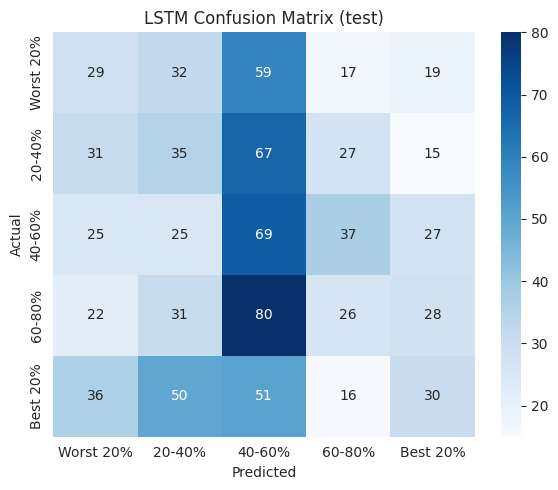

In [21]:
# LSTM confusion matrix on the test set
cm = confusion_matrix(yte, lstm_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title("LSTM Confusion Matrix (test)")
plt.tight_layout(); plt.show()

## 11. Regime-Stratified View (LSTM)

Same honest caveat as the logistic notebook: with one chronological split, COVID and the 2022
bear fall in the **training** window, so their scores are in-sample (optimistic). Only the recent
window is true out-of-sample. The full report will use walk-forward so every regime is scored
fairly. This is a first look.

In [22]:
all_pred = model.predict(X, verbose=0).argmax(1)
regimes = {
    "COVID crash (2020)":   ("2020-02-19", "2020-04-30"),
    "2022 bear":            ("2022-01-03", "2022-10-12"),
    "AI rally (2023-2024)": ("2023-01-01", "2024-12-31"),
    "Recent (2025+)":       ("2025-01-01", str(pd.Timestamp(END).date())),
}
dts = pd.to_datetime(dates_all)
rows = []
for name, (a, b) in regimes.items():
    m = (dts >= pd.Timestamp(a)) & (dts <= pd.Timestamp(b))
    if m.sum() == 0:
        continue
    yy, pp, ss = y[m], all_pred[m], split_all[m]
    dominant = pd.Series(ss).value_counts(normalize=True).idxmax()
    rows.append({
        "regime": name, "n": int(m.sum()),
        "lstm_acc": round(accuracy_score(yy, pp), 3),
        "lstm_macroF1": round(f1_score(yy, pp, average="macro"), 3),
        "window": "out-of-sample" if dominant == "test" else "in-sample",
    })
regime_tbl = pd.DataFrame(rows)
print(regime_tbl.to_string(index=False))

              regime    n  lstm_acc  lstm_macroF1        window
           2022 bear  784     0.316         0.277     in-sample
AI rally (2023-2024) 2008     0.276         0.271     in-sample
      Recent (2025+) 1460     0.227         0.219 out-of-sample


**Takeaway.** Read the out-of-sample (recent) row as the honest number; the in-sample
regimes look better only because the model trained on them. Whether the LSTM beats the logistic
baseline on the recent window is the result that matters, and the walk-forward version will let
us make that claim across every regime.

## 12. Next Steps

1. Wrap both models in walk-forward (expanding-window) validation so the regime comparison
   is fully out-of-sample.
2. Add the remaining rubric models (Random Forest, XGBoost) on the same flat features.
3. Try a `Bidirectional(LSTM(...))` layer (cite Sunny et al. 2020) and a light hyperparameter
   sweep (window 20 vs 30, LSTM units, dropout).
4. Add market-wide context features (volatility, a rate proxy, a credit proxy), joined on the
   same date to stay look-ahead safe.
5. Merge with teammates